In [1]:
from pymatgen.io.vasp import Vasprun
from pymatgen.electronic_structure.core import Spin, Orbital
import numpy as np

# 1. Load VASP result (vasprun.xml)
v = Vasprun("vasprun_nolim_lno.xml", parse_dos=True, parse_eigen=True)
cdos = v.complete_dos
energies = cdos.energies - cdos.efermi  # Fermi level -> 0

# 2. PDOS Preparation
li_indices = [i for i, site in enumerate(v.final_structure) if site.specie.symbol == "Li"]
o_indices = [i for i, site in enumerate(v.final_structure) if site.specie.symbol == "O"]
fe_indices = [i for i, site in enumerate(v.final_structure) if site.specie.symbol == "Fe"]
ni_indices = [i for i, site in enumerate(v.final_structure) if site.specie.symbol == "Ni"]

indices = {'li_indices' : li_indices, 'o_indices' : o_indices, 
           'fe_indices' : fe_indices, 'ni_indices' : ni_indices}

target_orbitals = {
    'li_indices' : [Orbital.s],
    'o_indices' : [Orbital.px, Orbital.py, Orbital.pz],
    'fe_indices' : [Orbital.dxy, Orbital.dyz, Orbital.dxz, Orbital.dz2, Orbital.dx2],
    'ni_indices' : [Orbital.dxy, Orbital.dyz, Orbital.dxz, Orbital.dz2, Orbital.dx2]
}

results = {}

# 3. PDOS Summation
for atom_type, index_list in indices.items() : 
    if not index_list :
        continue

    orbs_to_sum = target_orbitals.get(atom_type, [])

    sum_up = np.zeros_like(energies)
    sum_down = np.zeros_like(energies)

    for idx in index_list:
        site = v.final_structure[idx]
        site_orb_dos = cdos.pdos[site]

        for orb in orbs_to_sum:
            if orb in site_orb_dos:
                sum_up += site_orb_dos[orb][Spin.up]
                if Spin.down in site_orb_dos[orb]:
                    sum_down += site_orb_dos[orb][Spin.down]
    
    results[atom_type] = {
        'sum_up': sum_up,
        'sum_down' : sum_down,
        'avg_total' : (sum_up + sum_down) / len(index_list)
    }

# total DOS
total_up = cdos.densities[Spin.up]
total_down = np.zeros_like(total_up) # Non-magnetic 대비 초기화
if Spin.down in cdos.densities:
    total_down = cdos.densities[Spin.down]


/home/sowon-laptop/anaconda3/envs/vscode/lib/python3.12/site-packages/pymatgen/io/vasp/outputs.py:1327: UserWarning: No POTCAR file with matching TITEL fields was found in

  if potcar := self.get_potcars(path):
/home/sowon-laptop/anaconda3/envs/vscode/lib/python3.12/site-packages/pymatgen/io/vasp/outputs.py:1338: UserWarning: No POTCAR file with matching TITEL fields was found in

  potcar = self.get_potcars(path)


In [2]:
#print(results['li_indices']['sum_up'])
print(cdos.efermi)

-1.84944836


<>:19: SyntaxWarning: invalid escape sequence '\m'
<>:19: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_25084/2048878864.py:19: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel('Energy ($\mathbf{E - E_F}$, eV)', fontsize=14)


Saved as PDOS_result_Ne+Fe_line.png.


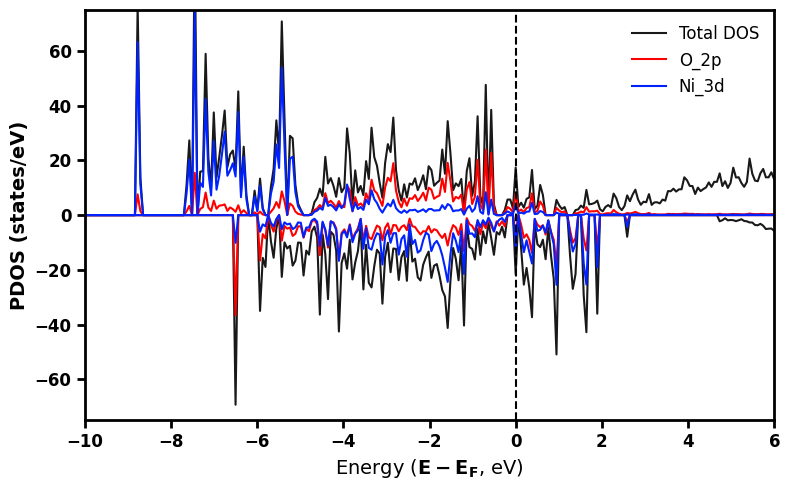

In [3]:
import matplotlib.pyplot as plt

# 4. Plotting
plt.figure(figsize=(8, 5)) 

plt.plot(energies, total_up, color='black', alpha =0.9, label='Total DOS')
plt.plot(energies, -total_down, color='black', alpha=0.9)
plt.plot(energies, results['o_indices']['sum_up'], color="#FF0000", label='O_2p')
plt.plot(energies, -results['o_indices']['sum_down'], color="#FF0000")
#plt.plot(energies, results['fe_indices']['sum_up'], color="#D343FF", label='Fe_3d')
#plt.plot(energies, -results['fe_indices']['sum_down'], color="#D343FF")
plt.plot(energies, results['ni_indices']['sum_up'], color="#0022FF", label='Ni_3d')
plt.plot(energies, -results['ni_indices']['sum_down'], color="#0022FF")

plt.axvline(0, color='black', linestyle='--', lw=1.5)

plt.xlim(-10, 6)  
plt.ylim(-75, 75)
plt.xlabel('Energy ($\mathbf{E - E_F}$, eV)', fontsize=14)
plt.ylabel('PDOS (states/eV)', fontsize=14, fontweight='bold')
plt.legend(frameon=False, fontsize=12 )

ax = plt.gca()
line_width = 2.0 
for spine in ax.spines.values():
    spine.set_linewidth(line_width)
ax.tick_params(axis='both', which='major', labelsize=12, width=line_width, length=6)
for label in ax.get_xticklabels():
    label.set_fontweight('bold')
for label in ax.get_yticklabels():
    label.set_fontweight('bold')
plt.tight_layout()

img_name = "PDOS_result_Ne+Fe_line.png" 
plt.savefig(img_name, dpi=300)
print(f"Saved as {img_name}.")
plt.show()

In [4]:
## Ni, Fe 묶어서 구함
# eg, t2g of transition metal
# 2. PDOS Preparation

d_index = [i for i, site in enumerate(v.final_structure) 
           if site.specie.symbol == "Fe" or site.specie.symbol == "Ni"]
#d_indices = {'fe_indices' : fe_indices, 'ni_indices' : ni_indices}

t2g_list = [Orbital.dxy, Orbital.dyz, Orbital.dxz]
eg_list = [Orbital.dz2, Orbital.dx2] # dx2 = d(x2-y2)

d_results = {}

# 3. PDOS Summation
t2g_up = np.zeros_like(energies)
t2g_down = np.zeros_like(energies)
eg_up = np.zeros_like(energies)
eg_down = np.zeros_like(energies)

for idx in index_list:
    site = v.final_structure[idx]
    site_orb_dos = cdos.pdos[site]

    for orb in t2g_list:
        if orb in site_orb_dos:
            if Spin.up in site_orb_dos[orb]:
                t2g_up += site_orb_dos[orb][Spin.up]
            if Spin.down in site_orb_dos[orb]:
                t2g_down += site_orb_dos[orb][Spin.down]
    for orb in eg_list:
        if orb in site_orb_dos:
            if Spin.up in site_orb_dos[orb]:
                eg_up += site_orb_dos[orb][Spin.up]
            if Spin.down in site_orb_dos[orb]:
                eg_down += site_orb_dos[orb][Spin.down]

d_results = {
    't2g_up': t2g_up,
    't2g_down' : t2g_down,
    'eg_up': eg_up,
    'eg_down' : eg_down,
    't2g_avg_total' : (t2g_up + t2g_down) / len(index_list),
    'eg_avg_total' : (eg_up + eg_down) / len(index_list)
    }

In [5]:
#test 
from scipy.integrate import simpson

# 1. Mask if E-Ef <= 0 
mask = energies <= 0
occ_energies = energies[mask]


# 2. t2g & eg Integral area
t2g_area = simpson(y=d_results['t2g_up'][mask], x=occ_energies) /len(d_index) \
    + simpson(y=d_results['t2g_down'][mask], x=occ_energies) /len(d_index)
eg_area = simpson(y=d_results['eg_up'][mask], x=occ_energies)/len(d_index) \
    + simpson(y=d_results['eg_down'][mask], x=occ_energies) /len(d_index)
eg_t2g_ratio = eg_area / t2g_area


print("\n" + "="*40)
print(f"1. t2g average: {t2g_area:.4f}")
print(f"2. eg average: {eg_area:.4f}")
print(f"3. eg/t2g: {eg_t2g_ratio:.4f}")
print("=" * 40)
#print(f"4. 정규화된 eg 점유율 (d7 기준): {normalized_eg:.4f}")
#print("="*40)


# 각 원자의 eg 점유율 리스트로 확인하기
individual_eg = []

for idx in d_index:
    site = v.final_structure[idx]
    site_orb_dos = cdos.pdos[site]
    
    # 해당 Ni의 eg 데이터만 추출
    single_eg_dos = np.zeros_like(energies)
    for orb in eg_list:
        if orb in site_orb_dos:
            if Spin.up in site_orb_dos[orb]:    
                single_eg_dos += site_orb_dos[orb][Spin.up]
            if Spin.down in site_orb_dos[orb]:
                single_eg_dos += site_orb_dos[orb][Spin.down]
    
    # 점유율 계산 (적분)
    mask = energies <= 0
    occ = simpson(y=single_eg_dos[mask], x=energies[mask])
    
    # 정규화 (d7 기준 비율 적용)
    # 개별 원자의 t2g도 구해야 정확하지만, 일단 단순 적분값으로 편차 확인
    individual_eg.append(occ)

print("Each Ni+Fe atoms eg integrated value:")
for i, val in enumerate(individual_eg):
    print(f"{d_index[i]}: {val:.4f}")


1. t2g average: 4.9629
2. eg average: 3.3128
3. eg/t2g: 0.6675
Each Ni+Fe atoms eg integrated value:
12: 3.0658
13: 2.9929
14: 3.0658
15: 3.7119
16: 3.7021
17: 3.7119
18: 3.1451
19: 3.2444
20: 3.1451
21: 3.4922
22: 2.9843
23: 3.4922


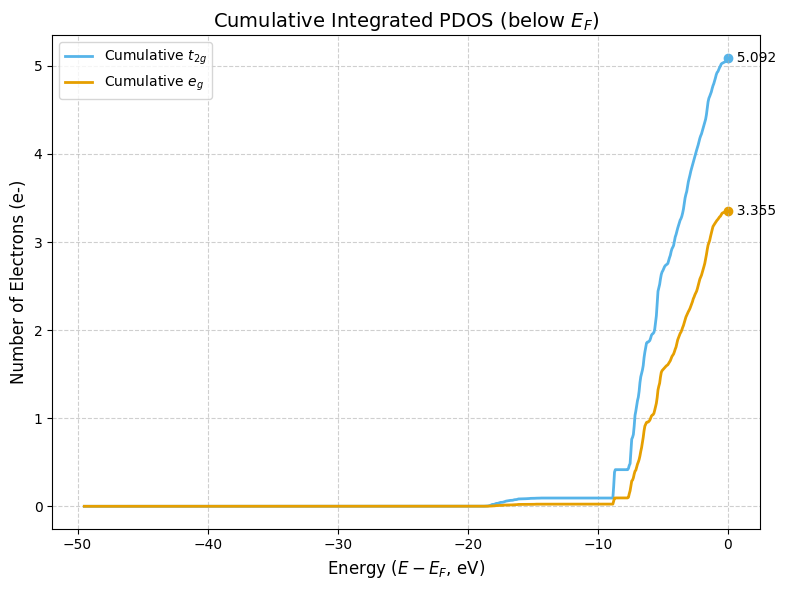

In [6]:
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid

# 1. 페르미 레벨(0 eV) 이하 데이터 추출
mask = energies <= 0
occ_e = energies[mask]

# 2. t2g와 eg의 전체 DOS 합산 (Up + Down)
# d_index로 나누어 평균적인 한 원자당 DOS로 계산
t2g_total_dos = (d_results['t2g_up'][mask] + d_results['t2g_down'][mask]) / len(d_index)
eg_total_dos = (d_results['eg_up'][mask] + d_results['eg_down'][mask]) / len(d_index)

# 3. 누적 적분 계산 (initial=0을 주어 시작점을 0으로 맞춤)
t2g_cumulative = cumulative_trapezoid(y=t2g_total_dos, x=occ_e, initial=0)
eg_cumulative = cumulative_trapezoid(y=eg_total_dos, x=occ_e, initial=0)

# 4. 시각화
plt.figure(figsize=(8, 6))

# 누적 그래프 plot
plt.plot(occ_e, t2g_cumulative, label='Cumulative $t_{2g}$', color='#56B4E9', lw=2)
plt.plot(occ_e, eg_cumulative, label='Cumulative $e_g$', color='#E69F00', lw=2)

# 최종 적분값 지점에 점 찍기
plt.scatter(occ_e[-1], t2g_cumulative[-1], color='#56B4E9')
plt.scatter(occ_e[-1], eg_cumulative[-1], color='#E69F00')

# 텍스트 표시
plt.text(occ_e[-1], t2g_cumulative[-1], f'  {t2g_cumulative[-1]:.3f}', va='center')
plt.text(occ_e[-1], eg_cumulative[-1], f'  {eg_cumulative[-1]:.3f}', va='center')

plt.title("Cumulative Integrated PDOS (below $E_F$)", fontsize=14)
plt.xlabel("Energy ($E - E_F$, eV)", fontsize=12)
plt.ylabel("Number of Electrons (e-)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
from scipy.integrate import quad
from scipy.interpolate import interp1d

# 1. 마스킹 및 에너지 설정
mask = energies <= 0
occ_energies = energies[mask]

def get_precise_integral(y_data, x_data):
    if len(x_data) < 2: return 0
    # 데이터 포인트 사이를 3차 곡선으로 보간
    f_interp = interp1d(x_data, y_data, kind='cubic', fill_value="extrapolate")
    # quad 적분 실행 (함수, 시작값, 끝값)
    val, _ = quad(f_interp, x_data[0], x_data[-1])
    return val

# 2. t2g & eg Integral area (문자열 키를 사용하여 딕셔너리 접근)
# d_results['t2g_up'] 처럼 따옴표를 붙여야 합니다.

# t2g 적분 (Up + Down)
t2g_up_val = get_precise_integral(d_results['t2g_up'][mask], occ_energies)
t2g_down_val = get_precise_integral(d_results['t2g_down'][mask], occ_energies)
t2g_area = (t2g_up_val + t2g_down_val) / len(d_index)

# eg 적분 (Up + Down)
eg_up_val = get_precise_integral(d_results['eg_up'][mask], occ_energies)
eg_down_val = get_precise_integral(d_results['eg_down'][mask], occ_energies)
eg_area = (eg_up_val + eg_down_val) / len(d_index)

# 비율 계산
eg_t2g_ratio = eg_area / t2g_area if t2g_area != 0 else 0

print(f"t2g Area: {t2g_area:.6f}")
print(f"eg Area: {eg_area:.6f}")
print(f"Ratio (eg/t2g): {eg_t2g_ratio:.6f}")

# 각 원자의 eg 점유율 리스트로 확인하기
individual_eg = []

for idx in d_index:
    site = v.final_structure[idx]
    site_orb_dos = cdos.pdos[site]
    
    # 해당 Ni의 eg 데이터만 추출
    single_eg_dos = np.zeros_like(energies)
    for orb in eg_list:
        if orb in site_orb_dos:
            single_eg_dos += site_orb_dos[orb][Spin.up]
            if Spin.down in site_orb_dos[orb]:
                single_eg_dos += site_orb_dos[orb][Spin.down]
    
    # 점유율 계산 (적분)
    mask = energies <= 0
    occ = simpson(y=single_eg_dos[mask], x=energies[mask])
    
    # 정규화 (d7 기준 비율 적용)
    # 개별 원자의 t2g도 구해야 정확하지만, 일단 단순 적분값으로 편차 확인
    individual_eg.append(occ)

print("Each Ni+Fe atoms eg integrated value:")
for i, val in enumerate(individual_eg):
    print(f"{d_index[i]}: {val:.4f}")



t2g Area: 5.080642
eg Area: 3.352982
Ratio (eg/t2g): 0.659952
Each Ni+Fe atoms eg integrated value:
12: 3.0658
13: 2.9929
14: 3.0658
15: 3.7119
16: 3.7021
17: 3.7119
18: 3.1451
19: 3.2444
20: 3.1451
21: 3.4922
22: 2.9843
23: 3.4922


/tmp/ipykernel_25084/1418485599.py:13: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  val, _ = quad(f_interp, x_data[0], x_data[-1])


<>:22: SyntaxWarning: invalid escape sequence '\m'
<>:22: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_25084/1165998750.py:22: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel('Energy ($\mathbf{E - E_F}$, eV)', fontsize=14)


KeyError: 'fe_indices'

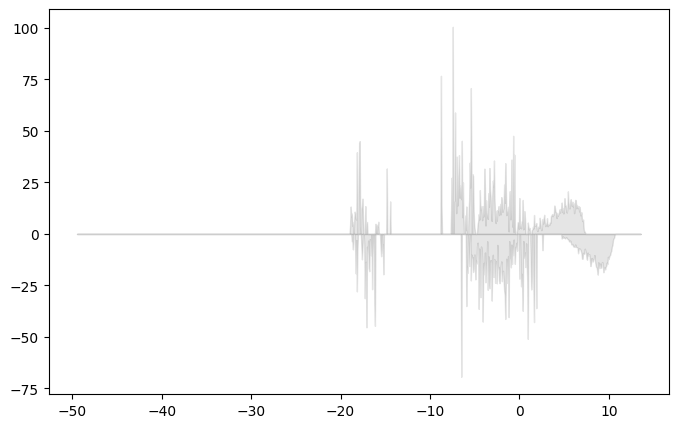

In [8]:
import matplotlib.pyplot as plt

# 4. Plotting
plt.figure(figsize=(8, 5)) # (8,5)x1.5
plt.fill_between(energies, total_up, color='black', alpha=0.1, label='Total DOS')
plt.fill_between(energies, -total_down, color='black', alpha=0.1)

plt.fill_between(energies, d_results['fe_indices']['t2g_up'], color="#56B4E9", alpha=0.5, label='t2g')
plt.fill_between(energies, -d_results['fe_indices']['t2g_down'], color="#56B4E9", alpha=0.5)
plt.fill_between(energies, d_results['ni_indices']['t2g_up'], color="#56B4E9", alpha=0.5)
plt.fill_between(energies, -d_results['ni_indices']['t2g_down'], color="#56B4E9", alpha=0.5)

plt.fill_between(energies, d_results['fe_indices']['eg_up'], color="#E69F00", label='eg')
plt.fill_between(energies, -d_results['fe_indices']['eg_down'], color="#E69F00")
plt.fill_between(energies, d_results['ni_indices']['eg_up'], color="#E69F00")
plt.fill_between(energies, -d_results['ni_indices']['eg_down'], color="#E69F00")

plt.axvline(0, color='black', linestyle='--', lw=1.5)

plt.xlim(-10, 6)  
plt.ylim(None, None)
plt.xlabel('Energy ($\mathbf{E - E_F}$, eV)', fontsize=14)
plt.ylabel('PDOS (states/eV)', fontsize=14, fontweight='bold')
plt.legend(frameon=False, fontsize=12 )

ax = plt.gca()
line_width = 2.0 
for spine in ax.spines.values():
    spine.set_linewidth(line_width)
ax.tick_params(axis='both', which='major', labelsize=12, width=line_width, length=6)
for label in ax.get_xticklabels():
    label.set_fontweight('bold')
for label in ax.get_yticklabels():
    label.set_fontweight('bold')
plt.tight_layout()

img_name = "PDOS_result_Ne+Fe_line.png" 
plt.savefig(img_name, dpi=300)
print(f"Saved as {img_name}.")
plt.show()